In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_labels.csv').values.ravel()
print(f"Loaded features: {X.shape}")
print(f"Loaded labels: {y.shape}")
print(f"Anomaly ratio: {y.mean():.2%}")

Loaded features: (10000, 28)
Loaded labels: (10000,)
Anomaly ratio: 50.00%


ELBOW METHOD - FINDING OPTIMAL K
Data shape: (10000, 28)
Testing k=2...
  Inertia: 176997.18, Silhouette: 0.4206
Testing k=3...
  Inertia: 133443.64, Silhouette: 0.3119
Testing k=4...
  Inertia: 121015.08, Silhouette: 0.2447
Testing k=5...
  Inertia: 112508.89, Silhouette: 0.2396
Testing k=6...
  Inertia: 106142.87, Silhouette: 0.2432
Testing k=7...
  Inertia: 101333.68, Silhouette: 0.2369
Testing k=8...
  Inertia: 97087.93, Silhouette: 0.2510
Testing k=9...
  Inertia: 94282.09, Silhouette: 0.1758
Testing k=10...
  Inertia: 89775.98, Silhouette: 0.2009


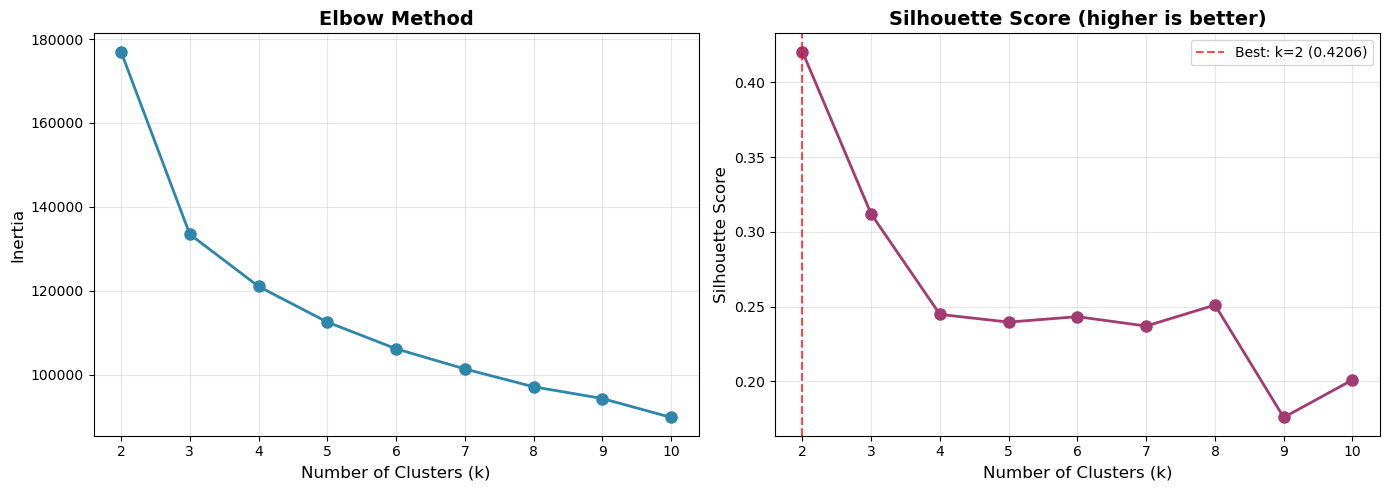


✅ Best k based on silhouette score: 2
   Silhouette score: 0.4206


In [4]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

print("="*60)
print("ELBOW METHOD - FINDING OPTIMAL K")
print("="*60)

# Convert X to numpy array if it's a DataFrame
if hasattr(X, 'values'):
    X_array = X.values
else:
    X_array = np.array(X)

print(f"Data shape: {X_array.shape}")

inertias = []
silhouette_scores = []
k_values = list(range(2, 11))

for k in k_values:
    print(f"Testing k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_array)
    inertias.append(kmeans.inertia_)
    
    sil_score = silhouette_score(X_array, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"  Inertia: {kmeans.inertia_:.2f}, Silhouette: {sil_score:.4f}")

# Convert to arrays
inertias = np.array(inertias)
silhouette_scores = np.array(silhouette_scores)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow curve
axes[0].plot(k_values, inertias, 'bo-', linewidth=2, markersize=8, color='#2E86AB')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_values)

# Plot 2: Silhouette scores
axes[1].plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=8, color='#A23B72')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score (higher is better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_values)

# Mark best k
best_k = k_values[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, 
                label=f'Best: k={best_k} ({silhouette_scores[np.argmax(silhouette_scores)]:.4f})')
axes[1].legend()

plt.tight_layout()

# Save
os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print(f"✅ Best k based on silhouette score: {best_k}")
print(f"   Silhouette score: {silhouette_scores[np.argmax(silhouette_scores)]:.4f}")
print("="*60)

In [5]:
optimal_k = 4
print(f"\nUsing k={optimal_k} for clustering...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Add cluster labels to data
X_with_clusters = X.copy()
X_with_clusters['cluster'] = cluster_labels
X_with_clusters['is_anomaly'] = y

print("\nCluster distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster in range(optimal_k):
    print(f"  Cluster {cluster}: {cluster_counts[cluster]:,} samples ({cluster_counts[cluster]/len(X):.1%})")



Using k=4 for clustering...

Cluster distribution:
  Cluster 0: 2,372 samples (23.7%)
  Cluster 1: 2,470 samples (24.7%)
  Cluster 2: 1,377 samples (13.8%)
  Cluster 3: 3,781 samples (37.8%)


CLUSTER ANALYSIS
Number of clusters: 4
Number of features: 28

Cluster Centers:
           Feature_0  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  \
Cluster_0      0.273      0.271      0.427      0.205      0.305      0.222   
Cluster_1     -0.714     -0.715     -0.708     -0.680     -0.652     -0.697   
Cluster_2      2.187      2.192      1.932      2.163      1.921      2.213   
Cluster_3     -0.502     -0.503     -0.511     -0.473     -0.467     -0.491   

           Feature_6  Feature_7  Feature_8  Feature_9  ...  Feature_18  \
Cluster_0      0.373      0.364      0.249      0.267  ...      -0.158   
Cluster_1     -0.653     -0.974     -0.698     -0.684  ...       0.006   
Cluster_2      1.813      0.073      2.096      2.147  ...      -0.045   
Cluster_3     -0.469      0.382     -0.465     -0.504  ...       0.112   

           Feature_19  Feature_20  Feature_21  Feature_22  Feature_23  \
Cluster_0      -0.165       0.041      -0.013       0.019      -0.016   
Cluster

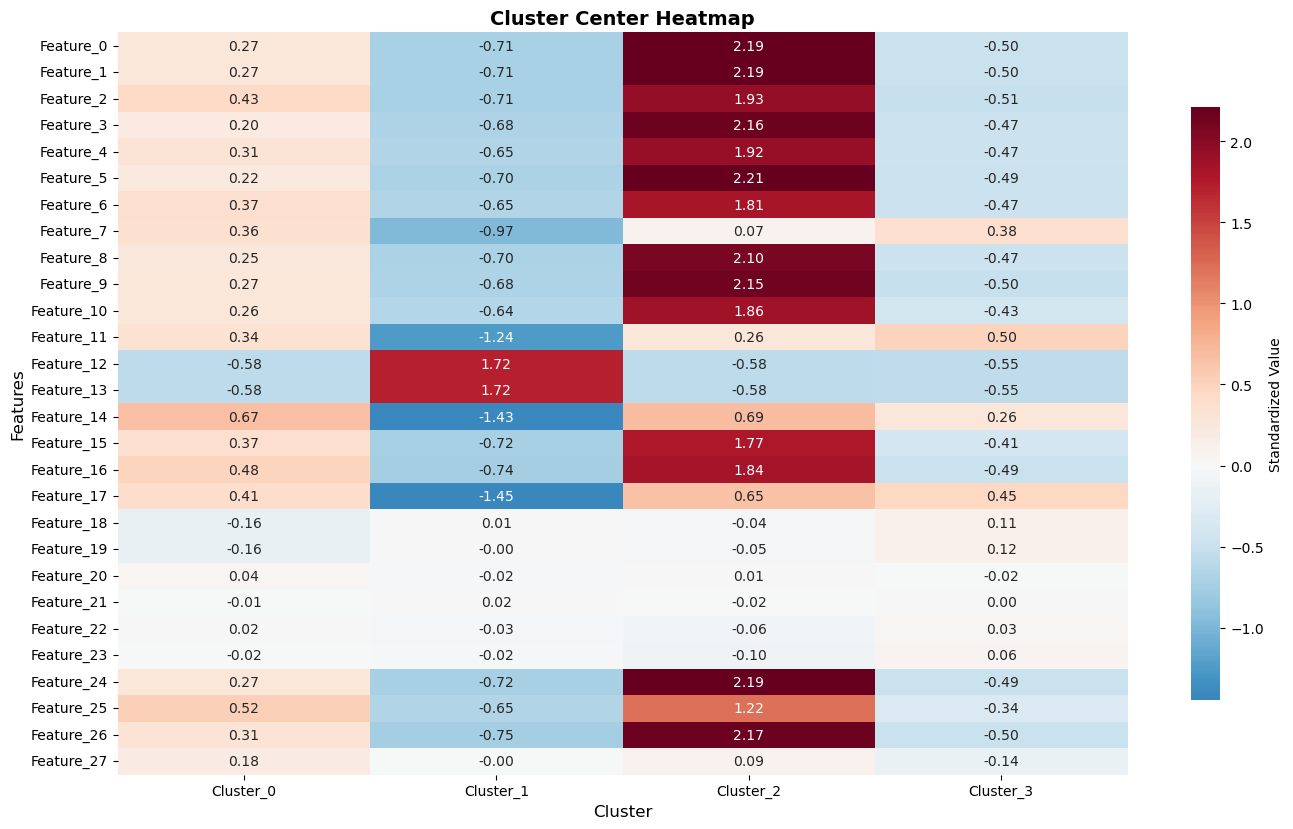


 Cluster centers visualization saved!


In [11]:
# ============================================
# CELL 5: Analyze Cluster Characteristics
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Get cluster centers
centers = kmeans.cluster_centers_
n_clusters, n_features = centers.shape

print("="*60)
print("CLUSTER ANALYSIS")
print("="*60)
print(f"Number of clusters: {n_clusters}")
print(f"Number of features: {n_features}")

# Create DataFrame with generic column names
cluster_centers_df = pd.DataFrame(
    centers,
    columns=[f'Feature_{i}' for i in range(n_features)],
    index=[f'Cluster_{i}' for i in range(n_clusters)]
)

print("\nCluster Centers:")
print(cluster_centers_df.round(3))

# Find distinguishing features per cluster
print("\n" + "="*60)
print("DISTINGUISHING FEATURES PER CLUSTER")
print("="*60)

for cluster_name in cluster_centers_df.index:
    cluster_data = cluster_centers_df.loc[cluster_name]
    # Get features with highest absolute values (most distinguishing)
    top_features = cluster_data.abs().sort_values(ascending=False).head(5)
    print(f"\n{cluster_name}:")
    for feat, val in top_features.items():
        direction = "↑" if cluster_data[feat] > 0 else "↓"
        print(f"  {direction} {feat}: {cluster_data[feat]:.3f}")

# Visualize
fig, ax = plt.subplots(figsize=(14, max(6, n_features * 0.3)))

heatmap = sns.heatmap(
    cluster_centers_df.T,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=ax,
    cbar_kws={'label': 'Standardized Value', 'shrink': 0.8}
)

ax.set_title('Cluster Center Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Features', fontsize=12)

plt.tight_layout()

os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/cluster_centers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Cluster centers visualization saved!")


Cluster 0: Anomaly rate = 49.75%
Cluster 1: Anomaly rate = 50.00%
Cluster 2: Anomaly rate = 47.13%
Cluster 3: Anomaly rate = 51.20%


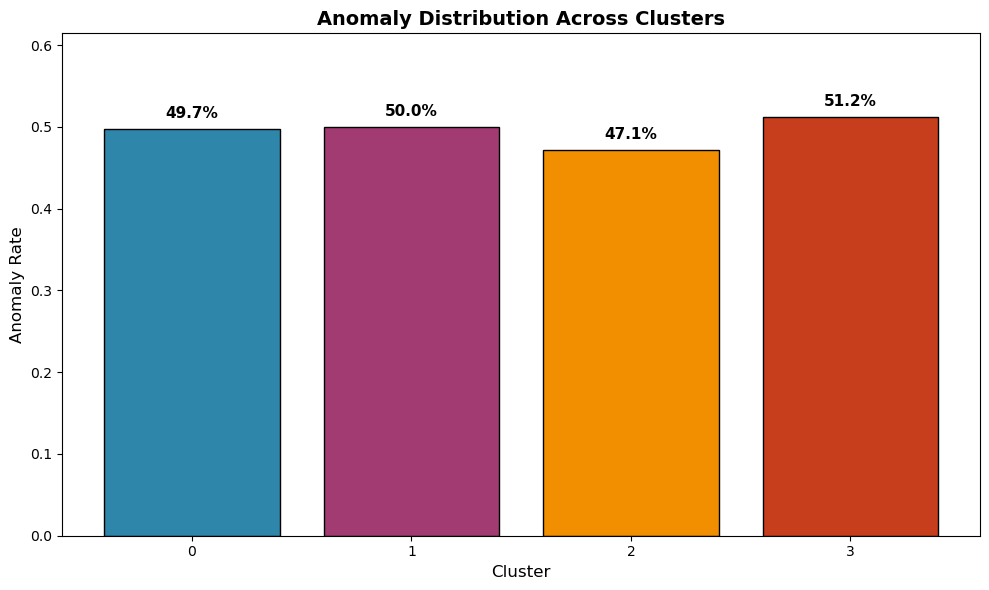

In [12]:
anomaly_rate_per_cluster = []
for cluster in range(optimal_k):
    cluster_mask = cluster_labels == cluster
    anomaly_rate = y[cluster_mask].mean()
    anomaly_rate_per_cluster.append(anomaly_rate)
    print(f"Cluster {cluster}: Anomaly rate = {anomaly_rate:.2%}")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(optimal_k), anomaly_rate_per_cluster, 
              color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'], 
              edgecolor='black')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Anomaly Rate', fontsize=12)
ax.set_title('Anomaly Distribution Across Clusters', fontsize=14, fontweight='bold')
ax.set_xticks(range(optimal_k))
ax.set_ylim(0, max(anomaly_rate_per_cluster) * 1.2)

# Add value labels
for bar, rate in zip(bars, anomaly_rate_per_cluster):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/anomaly_by_cluster.png', dpi=150)
plt.show()


PCA explained variance ratio:
  PC1: 49.81%
  PC2: 11.68%
  Total: 61.49%


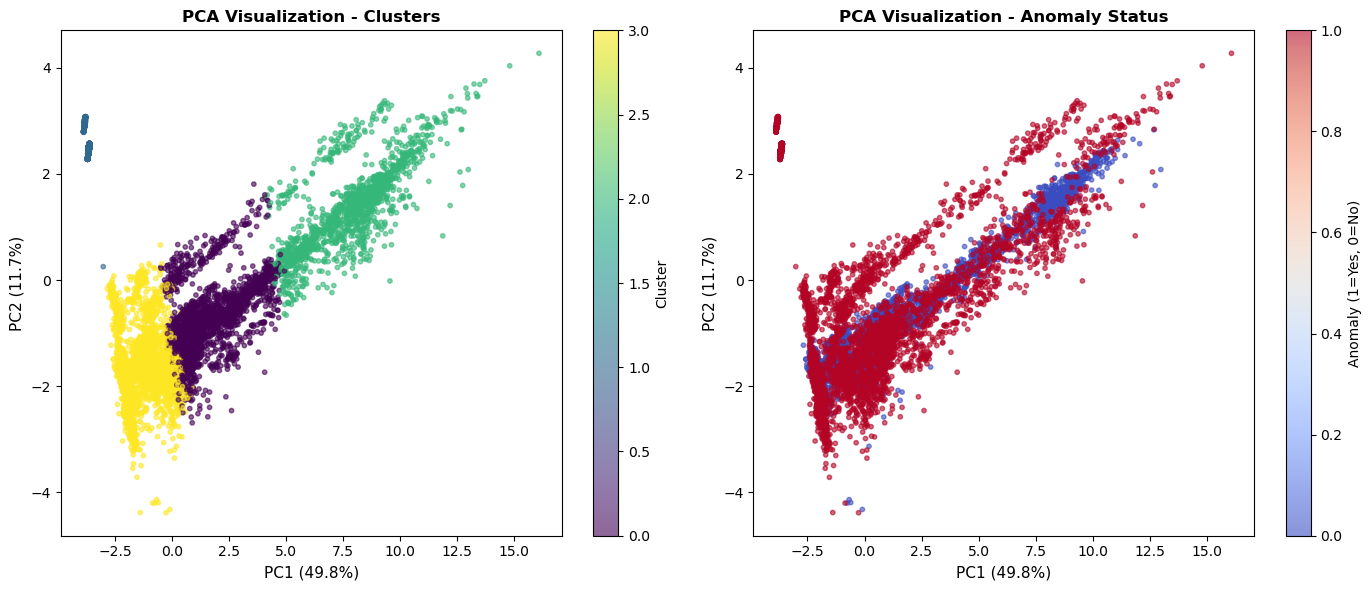

In [13]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.2%}")

# Plot clusters in PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot by cluster
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                           cmap='viridis', alpha=0.6, s=10)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0].set_title('PCA Visualization - Clusters', fontsize=12, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot by anomaly status
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, 
                           cmap='coolwarm', alpha=0.6, s=10)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[1].set_title('PCA Visualization - Anomaly Status', fontsize=12, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Anomaly (1=Yes, 0=No)')

plt.tight_layout()
plt.savefig('../data/processed/pca_visualization.png', dpi=150)
plt.show()


In [14]:
from scipy.spatial.distance import cdist

# Calculate distance to cluster center for each point
distances_to_center = np.min(cdist(X, kmeans.cluster_centers_), axis=1)

# Set threshold (95th percentile of normal distances)
normal_distances = distances_to_center[y == 0]
anomaly_threshold = np.percentile(normal_distances, 95)

print(f"\nDistance Statistics:")
print(f"  Mean distance to center: {distances_to_center.mean():.4f}")
print(f"  Std distance to center: {distances_to_center.std():.4f}")
print(f"  Anomaly threshold (95th percentile of normal): {anomaly_threshold:.4f}")

# Flag anomalies based on distance
distance_anomalies = distances_to_center > anomaly_threshold
print(f"  Distance-based anomalies detected: {distance_anomalies.sum():,} ({distance_anomalies.mean():.2%})")

# Compare with true labels (if in synthetic data)
true_positives = ((distance_anomalies == 1) & (y == 1)).sum()
false_positives = ((distance_anomalies == 1) & (y == 0)).sum()
false_negatives = ((distance_anomalies == 0) & (y == 1)).sum()

print(f"\nDistance-based detection performance (against synthetic labels):")
print(f"  True Positives: {true_positives}")
print(f"  False Positives: {false_positives}")
print(f"  False Negatives: {false_negatives}")
print(f"  Accuracy: {(true_positives + (len(y) - false_positives - false_negatives)) / len(y):.2%}")



Distance Statistics:
  Mean distance to center: 3.2661
  Std distance to center: 1.1975
  Anomaly threshold (95th percentile of normal): 4.4534
  Distance-based anomalies detected: 997 (9.97%)

Distance-based detection performance (against synthetic labels):
  True Positives: 747
  False Positives: 250
  False Negatives: 4253
  Accuracy: 62.44%


In [15]:
print("CLUSTER PROFILES")
print("="*60)

cluster_descriptions = []
for cluster in range(optimal_k):
    cluster_mask = cluster_labels == cluster
    cluster_data = X[cluster_mask]
    anomaly_rate = y[cluster_mask].mean()
    
    # Determine cluster type based on features
    avg_consumption = cluster_data['avg_consumption'].mean()
    variability = cluster_data['std_consumption'].mean()
    night_ratio = cluster_data['night_ratio'].mean()
    
    if avg_consumption > 0.5:
        consumption_level = "High"
    elif avg_consumption > 0.3:
        consumption_level = "Medium"
    else:
        consumption_level = "Low"
    
    if variability > 0.2:
        variability_desc = "Variable"
    else:
        variability_desc = "Stable"
    
    if night_ratio > 0.3:
        night_desc = "High Night Usage"
    elif night_ratio > 0.15:
        night_desc = "Normal Night Usage"
    else:
        night_desc = "Low Night Usage"
    
    if anomaly_rate > 0.5:
        risk = "VERY HIGH"
    elif anomaly_rate > 0.3:
        risk = "HIGH"
    elif anomaly_rate > 0.1:
        risk = "MEDIUM"
    else:
        risk = "LOW"
    
    print(f"\n--- Cluster {cluster} ---")
    print(f"  Size: {cluster_mask.sum():,} samples ({cluster_mask.sum()/len(X):.1%})")
    print(f"  Consumption: {consumption_level} ({avg_consumption:.3f})")
    print(f"  Pattern: {variability_desc}")
    print(f"  Night Usage: {night_desc}")
    print(f"  Anomaly Rate: {anomaly_rate:.2%}")
    print(f"  Risk Level: {risk}")
    
    cluster_descriptions.append({
        'cluster': cluster,
        'size': cluster_mask.sum(),
        'size_pct': cluster_mask.sum()/len(X),
        'anomaly_rate': anomaly_rate,
        'risk_level': risk,
        'consumption_level': consumption_level
    })

CLUSTER PROFILES

--- Cluster 0 ---
  Size: 2,372 samples (23.7%)
  Consumption: Low (0.272)
  Pattern: Variable
  Night Usage: High Night Usage
  Anomaly Rate: 49.75%
  Risk Level: HIGH

--- Cluster 1 ---
  Size: 2,470 samples (24.7%)
  Consumption: Low (-0.715)
  Pattern: Stable
  Night Usage: Low Night Usage
  Anomaly Rate: 50.00%
  Risk Level: HIGH

--- Cluster 2 ---
  Size: 1,377 samples (13.8%)
  Consumption: High (2.193)
  Pattern: Variable
  Night Usage: Normal Night Usage
  Anomaly Rate: 47.13%
  Risk Level: HIGH

--- Cluster 3 ---
  Size: 3,781 samples (37.8%)
  Consumption: Low (-0.502)
  Pattern: Stable
  Night Usage: High Night Usage
  Anomaly Rate: 51.20%
  Risk Level: VERY HIGH


In [16]:
import joblib
joblib.dump(kmeans, '../data/models/kmeans_model.pkl')
joblib.dump(anomaly_threshold, '../data/models/anomaly_threshold.pkl')
joblib.dump(cluster_labels, '../data/processed/cluster_labels.npy')
joblib.dump(distances_to_center, '../data/processed/distances_to_center.npy')

# Save cluster profiles
cluster_profiles_df = pd.DataFrame(cluster_descriptions)
cluster_profiles_df.to_csv('../data/processed/cluster_profiles.csv', index=False)

print("\n Clustering complete!")
print("Models saved:")
print("  - kmeans_model.pkl")
print("  - anomaly_threshold.pkl")
print("  - cluster_profiles.csv")


 Clustering complete!
Models saved:
  - kmeans_model.pkl
  - anomaly_threshold.pkl
  - cluster_profiles.csv
